In [1]:
import pandas as pd

df = pd.read_csv("BBC News Train.csv")
texts = df['Text'].astype(str).tolist()


In [2]:
print(len(texts))
print(texts[0][:400])


1490
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of


In [3]:
!pip install gensim nltk spacy pyLDAvis wordcloud matplotlib
!python -m spacy download en_core_web_sm


Defaulting to user installation because normal site-packages is not writeable
  Using cached pyLDAvis-3.4.1-py3-none-any.whl (2.6 MB)
  Using cached wordcloud-1.9.6-cp39-cp39-win_amd64.whl (306 kB)
  Using cached pandas-2.3.3-cp39-cp39-win_amd64.whl (11.4 MB)
  Using cached funcy-2.0-py2.py3-none-any.whl (30 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Traceback (most recent call last):
  File "C:\ProgramData\Anaconda3\lib\site-packages\urllib3\connectionpool.py", line 703, in urlopen
    httplib_response = self._make_request(
  File "C:\ProgramData\Anaconda3\lib\site-packages\urllib3\connectionpool.py", line 386, in _make_request
    self._validate_conn(conn)
  File "C:\ProgramData\Anaconda3\lib\site-packages\urllib3\connectionpool.py", line 1040, in _validate_conn
    conn.connect()
  File "C:\ProgramData\Anaconda3\lib\site-packages\urllib3\connection.py", line 414, in connect
    self.sock = ssl_wrap_socket(
  File "C:\ProgramData\Anaconda3\lib\site-packages\urllib3\util\ssl_.py", line 449, in ssl_wrap_socket
    ssl_sock = _ssl_wrap_socket_impl(
  File "C:\ProgramData\Anaconda3\lib\site-packages\urllib3\util\ssl_.py", line 493, in _ssl_wrap_socket_impl
    return ssl_context.wrap_socket(sock, server_hostname=server_hostname)
  File "C:\ProgramData\Anaconda3\lib\ssl.py", line 500, in wrap_socket
    return self.sslsocket_class._cr

In [5]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
stop_words = set(STOP_WORDS)



In [12]:
def preprocess_texts(texts):
    processed = []
    for doc in nlp.pipe(texts, batch_size=100):
        tokens = [
            token.lemma_
            for token in doc
            if (
                token.is_alpha
                and token.text not in stop_words
                and len(token.text) > 2
                and token.text not in ["mr"]
            )
        ]
        processed.append(tokens)
    return processed


In [13]:
processed_texts[0]


['worldcom',
 'ex',
 'boss',
 'launch',
 'defence',
 'lawyer',
 'defend',
 'worldcom',
 'chief',
 'bernie',
 'ebber',
 'battery',
 'fraud',
 'charge',
 'call',
 'company',
 'whistleblow',
 'witness',
 'cynthia',
 'cooper',
 'worldcom',
 's',
 'ex',
 'head',
 'internal',
 'accounting',
 'alert',
 'director',
 'irregular',
 'accounting',
 'practice',
 'telecom',
 'giant',
 'warning',
 'lead',
 'collapse',
 'firm',
 'follow',
 'discovery',
 'accounting',
 'fraud',
 'mr',
 'ebber',
 'plead',
 'guilty',
 'charge',
 'fraud',
 'conspiracy',
 'prosecution',
 'lawyer',
 'argue',
 'mr',
 'ebber',
 'orchestrate',
 'series',
 'accounting',
 'trick',
 'worldcom',
 'order',
 'employee',
 'hide',
 'expense',
 'inflate',
 'revenue',
 'meet',
 'wall',
 'street',
 'earning',
 'estimate',
 'ms',
 'cooper',
 'run',
 'consulting',
 'business',
 'tell',
 'jury',
 'new',
 'york',
 'wednesday',
 'external',
 'auditor',
 'arthur',
 'andersen',
 'approve',
 'worldcom',
 's',
 'account',
 'early',
 'say',
 'ande

In [18]:
processed_texts = preprocess_texts(texts)

In [19]:
from gensim import corpora

dictionary = corpora.Dictionary(processed_texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in processed_texts]


In [20]:
print(dictionary[0])
print(corpus[0])


account
[(0, 1), (1, 6), (2, 1), (3, 2), (4, 1), (5, 1), (6, 2), (7, 1), (8, 1), (9, 2), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 3), (20, 3), (21, 1), (22, 1), (23, 1), (24, 2), (25, 1), (26, 1), (27, 1), (28, 4), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 7), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 2), (43, 1), (44, 1), (45, 2), (46, 1), (47, 4), (48, 1), (49, 2), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 3), (62, 1), (63, 1), (64, 2), (65, 1), (66, 2), (67, 1), (68, 1), (69, 2), (70, 1), (71, 1), (72, 2), (73, 1), (74, 1), (75, 2), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 2), (87, 1), (88, 1), (89, 2), (90, 1), (91, 1), (92, 1), (93, 1), (94, 1), (95, 1), (96, 1), (97, 1), (98, 2), (99, 9), (100, 1)]


In [21]:
from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=10,
    random_state=42
)


In [22]:
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")


Topic 0: 0.011*"win" + 0.009*"game" + 0.008*"play" + 0.007*"time" + 0.007*"england" + 0.006*"player" + 0.006*"world" + 0.005*"good" + 0.005*"match" + 0.005*"go"
Topic 1: 0.021*"film" + 0.012*"good" + 0.010*"award" + 0.009*"star" + 0.008*"win" + 0.006*"include" + 0.006*"new" + 0.006*"actor" + 0.005*"music" + 0.005*"director"
Topic 2: 0.008*"company" + 0.007*"market" + 0.007*"firm" + 0.006*"rise" + 0.005*"sale" + 0.005*"country" + 0.005*"growth" + 0.005*"economy" + 0.005*"bank" + 0.005*"share"
Topic 3: 0.010*"election" + 0.009*"labour" + 0.009*"party" + 0.009*"government" + 0.007*"people" + 0.007*"blair" + 0.007*"minister" + 0.006*"tory" + 0.006*"plan" + 0.005*"new"
Topic 4: 0.011*"people" + 0.008*"mobile" + 0.008*"phone" + 0.007*"game" + 0.007*"technology" + 0.007*"service" + 0.007*"new" + 0.006*"use" + 0.005*"user" + 0.005*"music"


In [23]:
from gensim.models import CoherenceModel, LdaModel

def compute_coherence(k):
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=10,
        random_state=42
    )
    cm = CoherenceModel(
        model=lda,
        texts=processed_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()


In [25]:
topic_nums = range(2, 11)
scores = []

for k in topic_nums:
    score = compute_coherence(k)
    scores.append(score)


In [26]:
for k, s in zip(topic_nums, scores):
    print(f"Topics: {k}, Coherence: {s}")


Topics: 2, Coherence: 0.3324665463514488
Topics: 3, Coherence: 0.4168067423833839
Topics: 4, Coherence: 0.4003094488227163
Topics: 5, Coherence: 0.5916093681865144
Topics: 6, Coherence: 0.5508442536639724
Topics: 7, Coherence: 0.5519153324449766
Topics: 8, Coherence: 0.5222539314814116
Topics: 9, Coherence: 0.5113244314811033
Topics: 10, Coherence: 0.5716579016658542


In [27]:
import pandas as pd

coherence_df = pd.DataFrame({
    "Num Topics": topic_nums,
    "Coherence Score": scores
})

coherence_df


,Num Topics,Coherence Score
0,2,0.332467
1,3,0.416807
2,4,0.400309
3,5,0.591609
4,6,0.550844
5,7,0.551915
6,8,0.522254
7,9,0.511324
8,10,0.571658


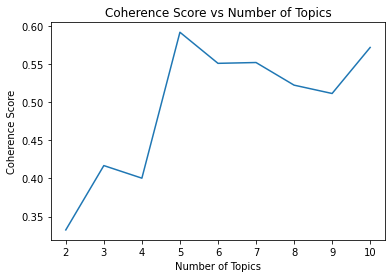

In [28]:
import matplotlib.pyplot as plt

plt.plot(topic_nums, scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence Score vs Number of Topics")
plt.show()


In [29]:
lda_final = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=10,
    random_state=42
)


In [30]:
lda_final.print_topics(num_words=10)



[(0,
  '0.011*"win" + 0.009*"game" + 0.008*"play" + 0.007*"time" + 0.007*"england" + 0.006*"player" + 0.006*"world" + 0.005*"good" + 0.005*"match" + 0.005*"go"'),
 (1,
  '0.021*"film" + 0.012*"good" + 0.010*"award" + 0.009*"star" + 0.008*"win" + 0.006*"include" + 0.006*"new" + 0.006*"actor" + 0.005*"music" + 0.005*"director"'),
 (2,
  '0.008*"company" + 0.007*"market" + 0.007*"firm" + 0.006*"rise" + 0.005*"sale" + 0.005*"country" + 0.005*"growth" + 0.005*"economy" + 0.005*"bank" + 0.005*"share"'),
 (3,
  '0.010*"election" + 0.009*"labour" + 0.009*"party" + 0.009*"government" + 0.007*"people" + 0.007*"blair" + 0.007*"minister" + 0.006*"tory" + 0.006*"plan" + 0.005*"new"'),
 (4,
  '0.011*"people" + 0.008*"mobile" + 0.008*"phone" + 0.007*"game" + 0.007*"technology" + 0.007*"service" + 0.007*"new" + 0.006*"use" + 0.005*"user" + 0.005*"music"')]

In [33]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

vis = gensimvis.prepare(
    lda_final,
    corpus,
    dictionary,
    n_jobs=1   
)

vis




C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\dtypes\cast.py:1841: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.063292  0.124735       1        1  21.968836
3     -0.036306 -0.060352       2        1  21.953510
2     -0.122916 -0.034014       3        1  21.394888
0      0.084862 -0.108035       4        1  20.273982
1      0.137652  0.077665       5        1  14.408784, topic_info=          Term        Freq        Total Category  logprob  loglift
355       film  820.000000   820.000000  Default  30.0000  30.0000
1762  election  557.000000   557.000000  Default  29.0000  29.0000
156     labour  535.000000   535.000000  Default  28.0000  28.0000
388     mobile  465.000000   465.000000  Default  27.0000  27.0000
655      award  380.000000   380.000000  Default  26.0000  26.0000
...        ...         ...          ...      ...      ...      ...
140         go  132.465052   741.386345   Topic5  -5.5977   0.2151
307       time  141.676986  1026.149274   Topic5  -5.5304  -0.0427
529        day  117.258824   468.881204   Topic5  -5.7196   0.5514
223        big  116.450403   539.767975   Topic5  -5.7265   0.4037
220        bbc  112.304102   477.619345   Topic5  -5.7628   0.4897

[382 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
4163      1  0.014744     academy
4163      2  0.029489     academy
4163      4  0.014744     academy
4163      5  0.943640     academy
1         3  0.962563  accounting
...     ...       ...         ...
1576      2  0.008380       yukos
1576      3  0.988883       yukos
2014      1  0.013329     zealand
2014      4  0.933034     zealand
2014      5  0.039987     zealand

[1139 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 3, 1, 2])